# **Reporte de Laboratorio 6 - Diseño de filtros para señales EMG y ECG**

# **1. Introducción**

<p align="justify">
  En este laboratorio se evaluará el desempeño de distintos filtros digitales para el preprocesamiento de señales biomédicas adquiridas con BITalino: 2 EMG y 2 ECG. Estas señales presentan artefactos típicos, deriva de línea base y movimiento (bajas frecuencias), interferencia de red (50/60 Hz) y ruido de alta frecuencia, por lo que el filtrado debe preservar la información fisiológica útil (morfología QRS/ondas P-T en ECG; activación y envolvente en EMG) minimizando distorsiones de fase/amplitud. Por ejemplo, en EMG es habitual trabajar en bandas cercanas a 20–400/450 Hz para retener contenido motor y atenuar artefactos lentos y ruido alto [1] [2].
</p>

<p align="justify">
  Se compararán diseños IIR (por ejemplo, Butterworth, Bessel, Chebyshev) y FIR (ventanas tipo Blackman). Los IIR logran especificaciones con menor orden (más eficiencia), pero suelen tener fase no lineal y requieren cuidado de estabilidad; pueden aplicarse en tiempo real con bajo costo [3]. Los FIR son siempre estables, permiten fase lineal (menor distorsión temporal) y son preferibles cuando la morfología/tiempos (onset, complejos QRS) son críticos, a cambio de órdenes mayores; en análisis off-line es común usar filtrado en dos pasadas para cero fase [3] [4]. Con base en respuestas de magnitud/fase, comparación antes/después y SNR espectral por bandas, se justificará el mejor filtro para cada señal.
</p>

# **2. Objetivos**
- Filtrar 4 señales (2 EMG, 2 ECG) con 4 diseños por señal y comparar.

- Graficar magnitud/fase, señal antes/después y espectro por filtro.

- Calcular SNR (dB) por bandas para cuantificar desempeño.

- Seleccionar y justificar el mejor filtro para cada señal.

# **3. Materiales**



# **4. Procedimiento**
Se detalla el procedimiento general con el código en Python para la obtención de las gráficas y los resultados a comparar en el presente laboratorio.

### **Ejemplo: Señal EMG 1 - Elevación Trapecio superior**

**Filtro para señal EMG: pasabanda 20 - 400 Hz.**
<p align="justify">
  Un pasabanda 20 - 400 Hz es un compromiso clásico para sEMG porque conserva la mayor parte del contenido fisiológico de la señal (actividad de unidades motoras) y, a la vez, atenúa lo que más contamina: deriva y artefactos de movimiento por debajo de ~20 Hz y ruido electrónico/alta frecuencia por encima de 400 Hz [5]. Con Fs = 1 kHz, ese LP en 400 Hz deja margen respecto a Nyquist (500 Hz) y evita amplificar componentes no informativos, resultando ideal para detección de activación, RMS/envolvente y análisis temporal estable [6], [7].
</p>

### **4.1 Importación de librerías**
Carga paquetes para cálculo numérico (NumPy), gráficos (Matplotlib), manejo de tablas (Pandas), filtrado digital (SciPy lfilter), utilidades estadísticas y barra de progreso (tqdm).

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import lfilter
import scipy.stats as stats
from tqdm import tqdm

### **4.2 Parámetros y carga**
Define la frecuencia de muestreo Fs y carga la señal EMG desde archivo; construye el vector de tiempo t según la longitud de la señal.

In [41]:
# Parámetros y carga
Fs = 1000  # Hz
emg1 = np.loadtxt("Señales/EMG_1.txt", usecols=[-1])
t = np.arange(len(emg1)) / Fs

### **4.3 Conversión ADC -> mV (BITalino EMG)**
Convierte cuentas del ADC (10 bits, Vcc=3.3 V) a milivoltios usando la ganancia del módulo EMG de BITalino; deja la señal en unidades físicas (mV).

In [42]:
# Conversión ADC -> mV (BITalino EMG)
# Parametros típicos BITalino (r)evolution:
N_BITS = 10
ADC_MAX = (2**N_BITS - 1)  # 1023
VCC    = 3.3               # Volts
G_EMG  = 1009.0            # Ganancia aproximada del sensor EMG

emg_mV = ((emg1.astype(float) / ADC_MAX) - 0.5) * VCC / G_EMG * 1000.0  # mV

### **4.4 Definir señal de análisis**
Selecciona un segmento temporal de interés (10 a 20 s por ejemplo corresponde al movimiento del músculo), para análisis y recorta el vector de tiempo correspondiente.

In [43]:
# Movimiento
inicio = int(10 * Fs)
fin    = int(20 * Fs)
x      = emg_mV[inicio:fin]      # señal en mV (Movimiento)
tt     = t[inicio:fin]

### **4.5 Filtros a usar (coeficientes exportados de pyFDA)**
Lista los filtros a comparar con sus rutas de coeficientes (CSV) exportados desde pyFDA: Butterworth, Bessel, Chebyshev I y un FIR con ventana Blackman.

In [44]:
# Filtros a usar (coeficientes exportados de pyFDA)
filtros = [
    ("Butterworth",  "Coeficientes/EMG_1.1_Butterworth.csv"),
    ("Bessel",       "Coeficientes/EMG_1.2_Bessel.csv"),
    ("Chebyshev I",  "Coeficientes/EMG_1.3_Chebyshev1.csv"),
    ("FIR Blackman", "Coeficientes/EMG_1.4_FIR_Blackman.csv"),
]

### **4.6 Aplicar cada filtro y guardar salidas**
Lee coeficientes b,a desde cada CSV, ajusta a=1 para el FIR puro y filtra el segmento x; almacena las señales filtradas con su etiqueta.

In [45]:
# Aplicar cada filtro y guardar salidas
ys = []  # lista de (label, y_filtrada)
for label, csv in filtros:
    f = pd.read_csv(csv, names=["b", "a"])
    b = f["b"].to_numpy()
    if label == "FIR Blackman":
        a = np.array([1.0])  # FIR tiene a=1
    else:
        a = f["a"].to_numpy()
    y = lfilter(b, a, x)
    ys.append((label, y))

### **4.7 Función SNR por FFT en banda de interés (20 - 400 Hz)**
Calcula el SNR en dB a partir de la FFT real: integra la potencia dentro de la banda útil (20 - 400 Hz) como “señal” y la potencia fuera de esa banda como “ruido”.

In [46]:
# Función SNR por FFT en banda de interés (20–400 Hz)
def calcular_snr_fft(senal, fs, f_low=20.0, f_high=400.0):
    x = np.asarray(senal)
    N = len(x)

    # FFT real
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, d=1.0/fs)

    # Limitar banda a [0, Fs/2]
    f_low  = max(0.0, float(f_low))
    f_high = min(fs/2.0, float(f_high))

    band = (freqs >= f_low) & (freqs <= f_high)

    # Potencias (magnitud^2)
    P_signal = np.sum(np.abs(X[band])**2)
    P_noise  = np.sum(np.abs(X[~band])**2)

    # SNR en dB con protección numérica
    snr_db = 10.0 * np.log10((P_signal + 1e-20) / (P_noise + 1e-20))
    return snr_db

### **4.8 Comparación de Señal EMG: Antes vs después del filtrado**

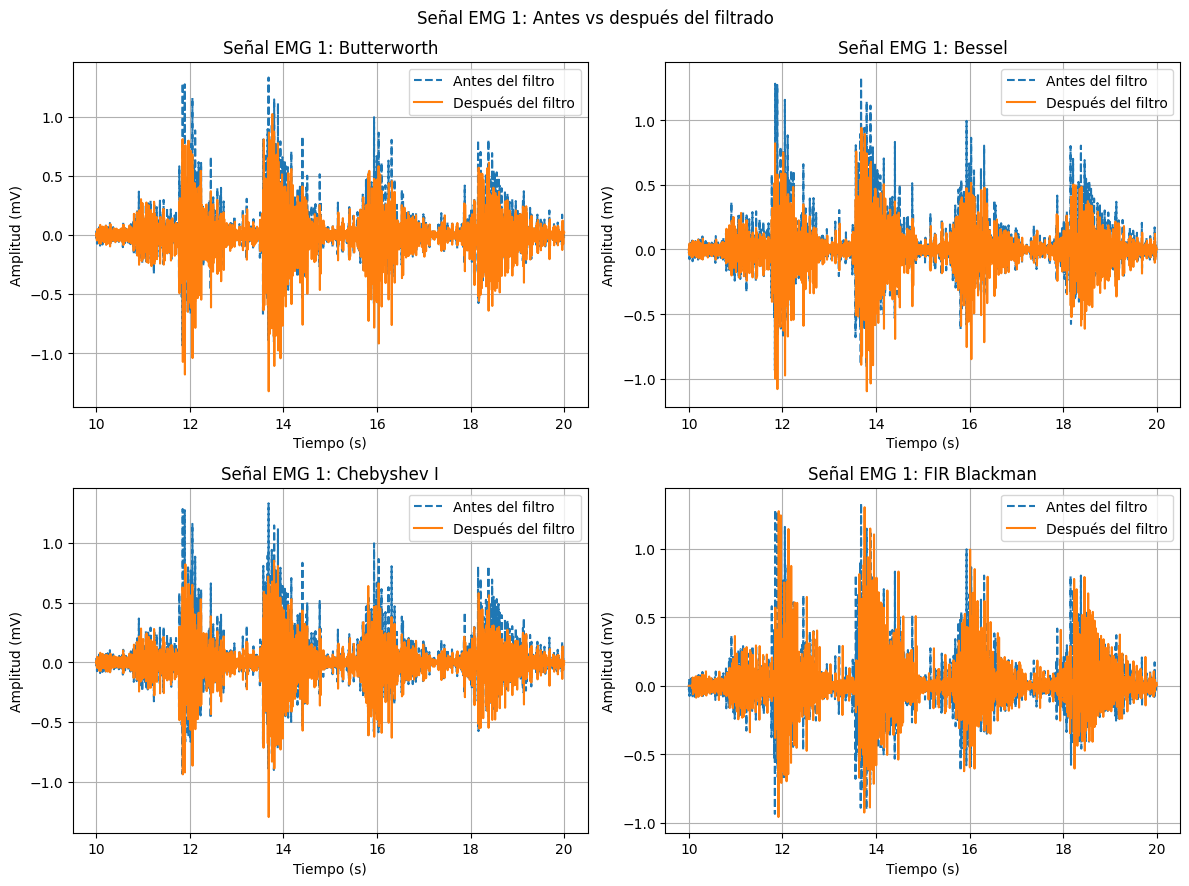

In [47]:
# 1. Señal antes vs después
plt.figure(figsize=(12, 9))
for i, (label, y) in enumerate(ys, start=1):
    plt.subplot(2, 2, i)
    plt.plot(tt, x, linestyle="--", label="Antes del filtro")
    plt.plot(tt, y, label="Después del filtro")
    plt.title(f"Señal EMG 1: {label}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud (mV)")
    plt.grid(True)
    plt.legend(loc="upper right")
plt.suptitle("Señal EMG 1: Antes vs después del filtrado")
plt.tight_layout()
plt.show()

### **4.9 Comparación de espectro de frecuencias: Antes vs después del filtrado**

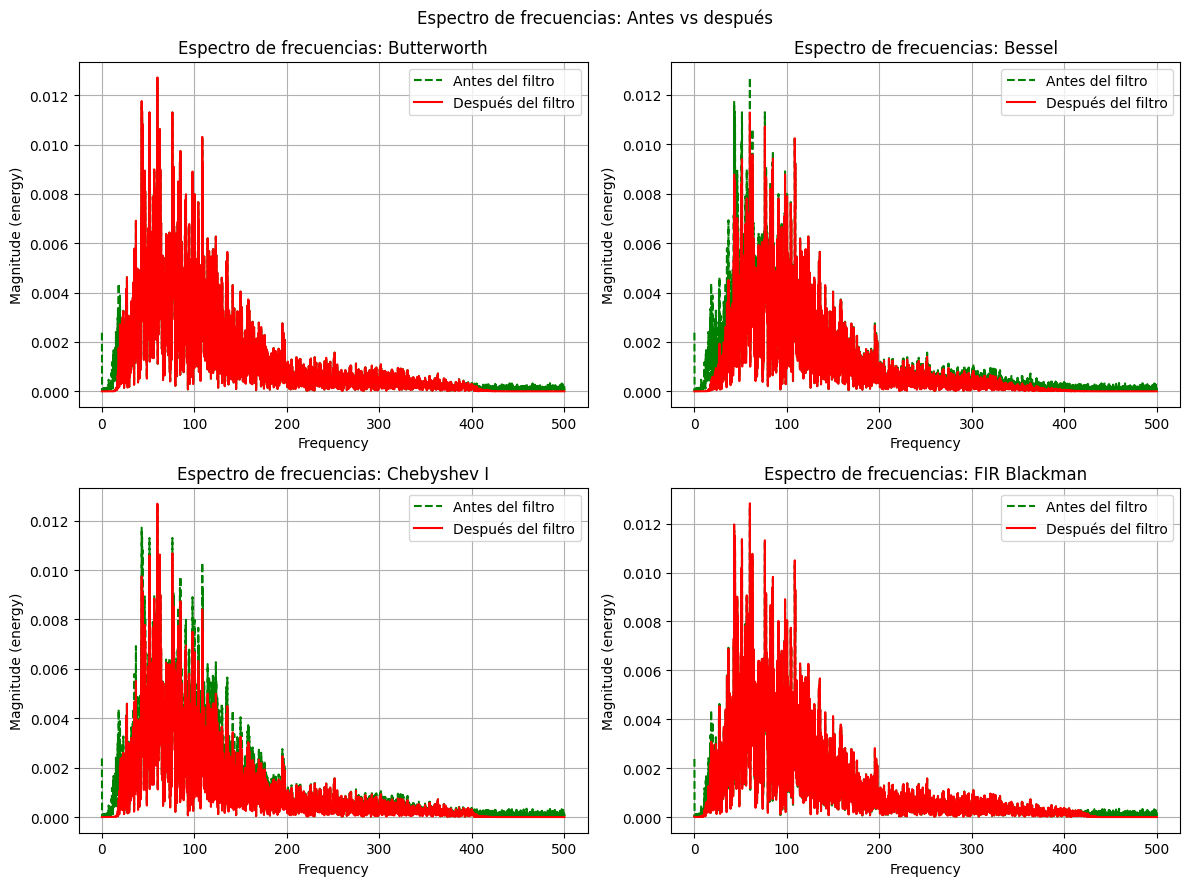

In [48]:
# 2. Espectro de frecuencias antes vs después
plt.figure(figsize=(12, 9))
for i, (label, y) in enumerate(ys, start=1):
    plt.subplot(2, 2, i)
    plt.magnitude_spectrum(x, Fs=Fs, color="green", ls="--", label="Antes del filtro")
    plt.magnitude_spectrum(y, Fs=Fs, color="red", label="Después del filtro")
    plt.title(f"Espectro de frecuencias: {label}")
    plt.grid(True)
    plt.legend(loc="upper right")
plt.suptitle("Espectro de frecuencias: Antes vs después")
plt.tight_layout()
plt.show()

### **4.10 SNR de la señal cruda y de cada salida filtrada**
Calcula el SNR en dB con el método espectral por bandas: primero para la señal cruda x y luego para cada señal filtrada en ys, integrando la potencia dentro de 20–450 Hz (señal) frente a la potencia fuera de esa banda (ruido). Imprime los resultados formateados por filtro para documentar cómo mejora (o no) la relación señal-ruido tras cada diseño de filtrado.

In [49]:
# SNR de la señal cruda y de cada salida filtrada
snr_raw_db = calcular_snr_fft(x, Fs, f_low=20, f_high=400)
print(f"SNR crudo (20 – 400 Hz): {snr_raw_db:.2f} dB")

for label, y in ys:
    snr_db = calcular_snr_fft(y, Fs, f_low=20, f_high=400)
    print(f"SNR {label} (20 – 400 Hz): {snr_db:.2f} dB")

SNR crudo (20 – 400 Hz): 17.66 dB
SNR Butterworth (20 – 400 Hz): 26.42 dB
SNR Bessel (20 – 400 Hz): 37.72 dB
SNR Chebyshev I (20 – 400 Hz): 29.46 dB
SNR FIR Blackman (20 – 400 Hz): 21.87 dB


# **5. Resultados**

## **5.1 Señal EMG 1 - Elevación Trapecio superior**
#### **5.1.1 Comparación de Magnitud (|H(f)|)**

<table>
  <tr>
    <td align="center">Butterworth<br>
      <img src="Filtros%20pyfda/EMG_1.1_magnitud.png" width="480">
    </td>
    <td align="center">Bessel<br>
      <img src="Filtros%20pyfda/EMG_1.2_magnitud.png" width="480">
    </td>
  </tr>
  <tr>
    <td align="center">Chebyshev I<br>
      <img src="Filtros%20pyfda/EMG_1.3_magnitud.png" width="480">
    </td>
    <td align="center">FIR Blackman<br>
      <img src="Filtros%20pyfda/EMG_1.4_magnitud.png" width="480">
    </td>
  </tr>
</table>

#### **5.1.2 Comparación de Fase (∠H(f))**

<table>
  <tr>
    <td align="center">Butterworth<br>
      <img src="Filtros%20pyfda/EMG_1.1_fase.png" width="480">
    </td>
    <td align="center">Bessel<br>
      <img src="Filtros%20pyfda/EMG_1.2_fase.png" width="480">
    </td>
  </tr>
  <tr>
    <td align="center">Chebyshev I<br>
      <img src="Filtros%20pyfda/EMG_1.3_fase.png" width="480">
    </td>
    <td align="center">FIR Blackman<br>
      <img src="Filtros%20pyfda/EMG_1.4_fase.png" width="480">
    </td>
  </tr>
</table>

#### **5.1.3 Comparación de la señal EMG antes vs después del filtrado**
<img src="Imágenes%20resultados/EMG_1.1.png">

#### **5.1.4 Comparación del espectro de frecuencias antes vs después del filtrado**
<img src="Imágenes%20resultados/EMG_1.2.png">

#### **5.1.5 Comparación del SNR de la señal cruda y de cada salida filtrada**
- SNR crudo (20–400 Hz): 17.85 dB
- SNR Butterworth (20–400 Hz): 26.55 dB
- SNR Bessel (20–400 Hz): 37.85 dB
- SNR Chebyshev I (20–400 Hz): 29.62 dB
- SNR FIR Blackman (20–400 Hz): 22.10 dB

# **6. Discusión de resultados**

## **6.1 Filtro EMG 1: Pasabanda de 20 - 400 Hz**
#### **6.1.1 Magnitud (|H(f)|):**
<p align="justify">
  Bessel y Butterworth presentan pasabandas estables y sin rizado, lo que favorece una ganancia uniforme dentro de 20–400 Hz. Chebyshev I introduce ondulaciones en pasabanda (rizado) que pueden alterar levemente la amplitud relativa de componentes EMG. FIR Blackman ofrece buena planitud si el orden es suficiente, pero con órdenes moderados puede recortar energía cerca de los bordes (20 y 400 Hz). En conjunto, para preservar la amplitud real en banda útil, Bessel o Butterworth son los más neutros.
</p>

#### **6.1.2 Fase (φ(f)):**
<p align="justify">
  La fase cercana a lineal de Bessel (entre los IIR) y la linealidad inherente del FIR permiten conservar mejor la morfología temporal (onset y picos). Butterworth y Chebyshev I exhiben mayor no linealidad de fase, si no se usa un filtrado cero-fase adicional, esto puede introducir pequeñas deformaciones temporales. Por lo tanto, para señales EMG donde la forma del pulso y su sincronía importan, el filtro Bessel o FIR son los que mejor se desempeñan.
</p>

#### **6.1.3 Señal en el tiempo (antes vs. después):**
<p align="justify">
  En la superposición temporal, Bessel mantiene la envolvente y los picos con mínima distorsión, mostrando un equilibrio entre limpieza y fidelidad. Butterworth es consistente y suave, aunque algo más difuso en transitorios. Chebyshev I puede mostrar pequeñas sobre/infra-ganancias locales (acorde a su rizado). FIR Blackman es el que mejor preserva la amplitud, pero depende de un gran orden de filtro.
</p>

#### **6.1.4 Espectro (antes vs. después):**
<p align="justify">
  Todos reducen con claridad el contenido fuera de 20-400 Hz. Bessel y Butterworth limpian sin ondulaciones notables en la banda útil. Chebyshev I puede reflejar ligeras oscilaciones espectrales en pasabanda. FIR Blackman puede da el piso espectral más limpio debido al gran orden que posee.
</p>

#### **6.1.4 SNR (20 - 400 Hz):**
<p align="justify">
  El SNR mejora respecto a la señal cruda (17.85 dB) para todos los filtros, destacando Bessel con 37.85 dB, seguido por Chebyshev I (29.62 dB), Butterworth (26.55 dB) y FIR Blackman (22.10 dB). Esto es coherente con la planitud en la magnitud y la fase favorable del Bessel.
</p>

#### **6.1.5 Conclusión:**
<p align="justify">
  Para EMG con pasabanda 20 - 400 Hz, el Bessel resulta el mejor compromiso debido a que posee un mayor SNR entre los candidatos (37.85 dB), tiene un pasabanda bastante plano (sin rizado) que preserva una amplitud en 20 - 400 Hz adecuada. Además, posee una fase casi lineal en banda, lo que conserva la morfología temporal (onset y picos EMG) mejor que otros IIR.
</p>

# **7. Referencias**

- [1] C. J. De Luca, L. D. Gilmore, M. Kuznetsov, and S. H. Roy, “Filtering the surface EMG signal: Movement artifact and baseline noise contamination,” J. Appl. Physiol., 2010.

- [2] P. Konrad, The ABC of EMG: A Practical Introduction to Kinesiological Electromyography, Noraxon, 2005.

- [3] A. V. Oppenheim and R. W. Schafer, Discrete-Time Signal Processing, 3rd ed., Pearson, 2010.

- [4] S. W. Smith, The Scientist and Engineer’s Guide to Digital Signal Processing, 2nd ed., 1999.

- [5] C. J. De Luca, L. D. Gilmore, M. Kuznetsov, and S. H. Roy, “Filtering the surface EMG signal: Movement artifact and baseline noise contamination,” J. Appl. Physiol., vol. 108, no. 2, pp. 652–659, 2010.

- [6] P. Konrad, The ABC of EMG: A Practical Introduction to Kinesiological Electromyography. Scottsdale, AZ: Noraxon, 2005.

- [7] H. J. Hermens, B. Freriks, C. Disselhorst-Klug, and G. Rau, “Development of recommendations for SEMG sensors and sensor placement,” J. Electromyogr. Kinesiol., vol. 10, no. 5, pp. 361–374, 2000.